<a href="https://colab.research.google.com/github/sreent/machine-learning/blob/main/Mid-Term%20Coursework%20Example.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Iris Dataset Analysis

## Data Preprocessing and EDA
This section involves loading the dataset, splitting it into training and testing sets, and standardizing the features. Standardization ensures that all features contribute equally to distance-based calculations in algorithms like kNN and logistic regression [1][2].

### Exploratory Data Analysis
EDA is crucial to understand the distribution and relationships of the features within the dataset. We start by checking the class balance to ensure that our dataset is not biased towards any particular class.

#### Class Balance
The bar plot of class distribution shows that the dataset is balanced, with 50 samples for each species. This balance justifies the use of accuracy as a metric for evaluating our models, as each class is equally represented [1].


In [72]:
# Import necessary libraries
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, learning_curve
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
from collections import Counter
import numpy as np
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.manifold import TSNE

# Load the dataset
iris = load_iris()
X = iris.data
y = iris.target

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize the features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Exploratory Data Analysis (EDA)
# Create a DataFrame for easier visualization
df = pd.DataFrame(X, columns=iris.feature_names)
df['species'] = y

# Check class balance
class_counts = df['species'].value_counts()
print("Class counts:\n", class_counts)


Class counts:
 species
0    50
1    50
2    50
Name: count, dtype: int64


#### Pair Plot
The pair plot visualizes the relationships between all feature pairs and how they relate to the target class. This helps in identifying potential patterns and separability among the classes.


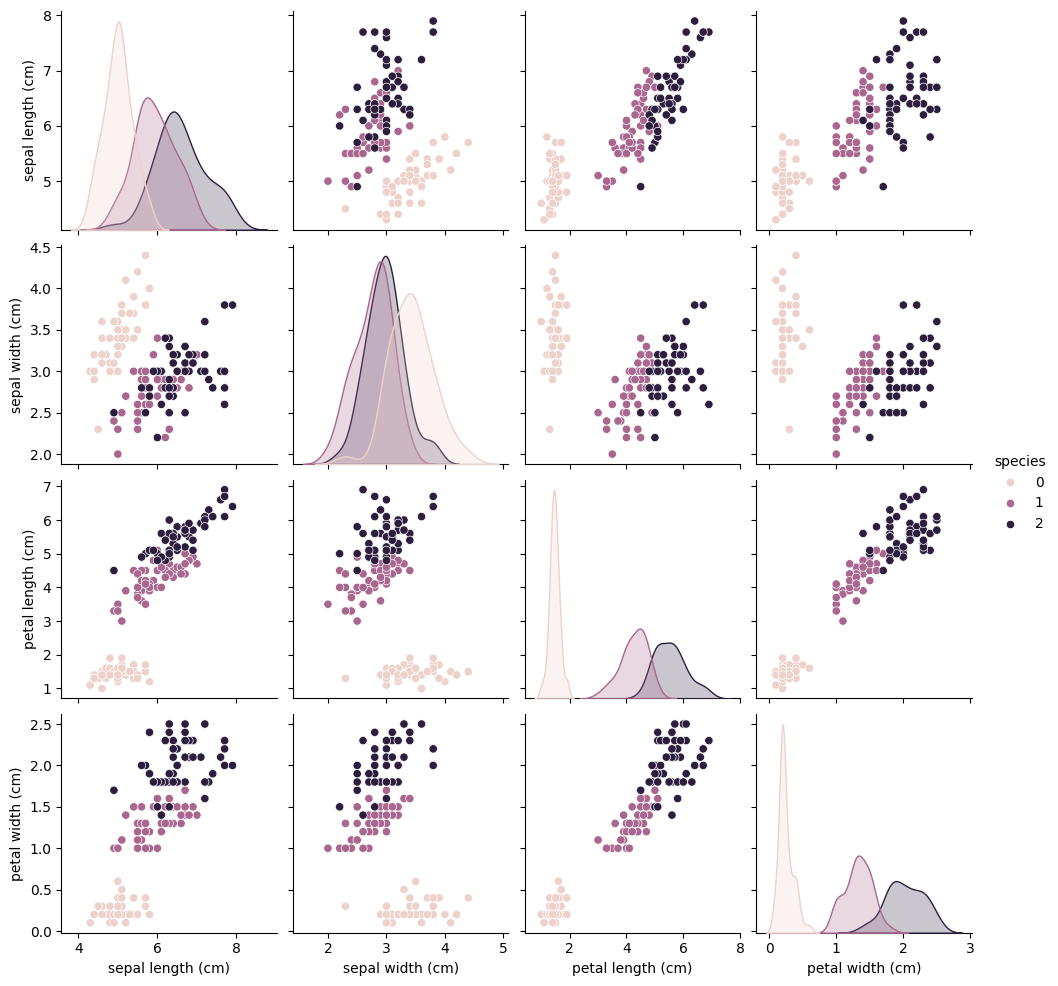

In [73]:
# Pairplot to visualize relationships between features
sns.pairplot(df, hue='species')
plt.show()


#### Correlation Heatmap
The correlation heatmap displays the correlation coefficients between the features. Features with high correlation coefficients can provide redundant information, while low correlations suggest independent information. This is crucial for understanding feature importance later [3].



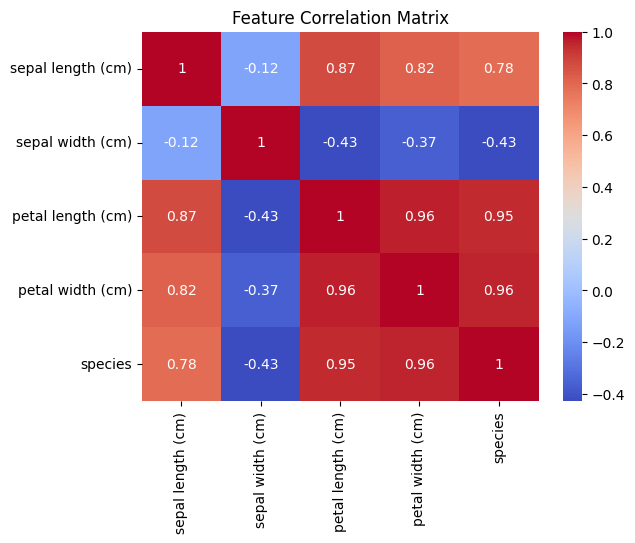

In [74]:
# Correlation heatmap
corr_matrix = df.corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title('Feature Correlation Matrix')
plt.show()


#### t-SNE Visualization
t-SNE (t-distributed Stochastic Neighbor Embedding) is used to visualize the dataset in two dimensions, helping us understand the separability of the classes. This visualization supports the discussion on why the models perform well on the Iris dataset [4].


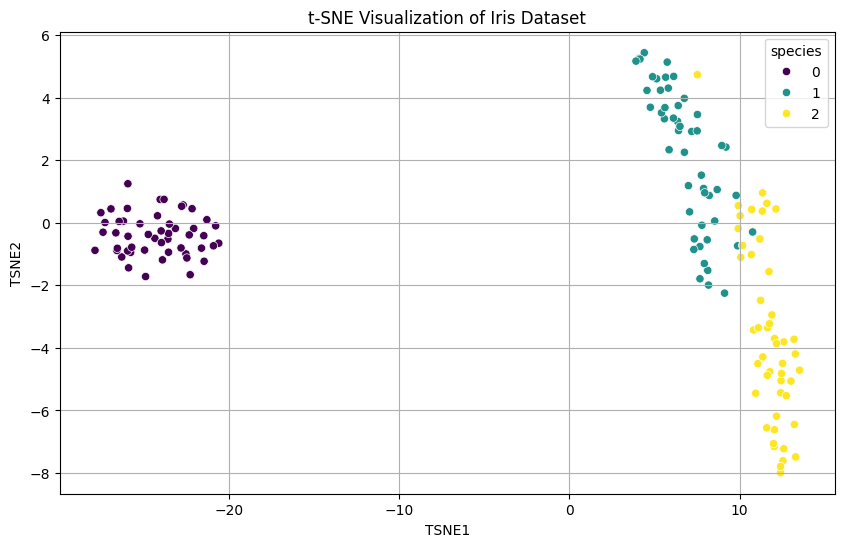

In [75]:
# t-SNE visualization
tsne = TSNE(n_components=2, random_state=42)
X_tsne = tsne.fit_transform(X)

# Create a DataFrame for t-SNE results
df_tsne = pd.DataFrame(X_tsne, columns=['TSNE1', 'TSNE2'])
df_tsne['species'] = y

# Plot t-SNE results
plt.figure(figsize=(10, 6))
sns.scatterplot(x='TSNE1', y='TSNE2', hue='species', palette='viridis', data=df_tsne)
plt.title('t-SNE Visualization of Iris Dataset')
plt.grid()
plt.show()

## Model Implementation and Evaluation
In this section, we implement the kNN and Naive Bayes classifiers from scratch, while using scikit-learn's implementations for the decision tree and logistic regression models. We also perform hyperparameter tuning using GridSearchCV for the kNN and logistic regression models to find the optimal parameters [5].



### Custom k-NN Classifier
The kNN classifier is implemented as a custom scikit-learn estimator. We perform hyperparameter tuning to find the optimal value of k using GridSearchCV [6].


In [76]:
from sklearn.base import BaseEstimator, ClassifierMixin
from collections import Counter
import numpy as np

class CustomKNNClassifier(BaseEstimator, ClassifierMixin):
    def __init__(self, k=3, metric='euclidean'):
        self.k = k
        self.metric = metric

    def fit(self, X, y):
        self.X_train = X
        self.y_train = y
        return self

    def predict(self, X):
        y_pred = []
        for x in X:
            if self.metric == 'euclidean':
                distances = [np.sqrt(np.sum((x - x_train) ** 2)) for x_train in self.X_train]
            elif self.metric == 'manhattan':
                distances = [np.sum(np.abs(x - x_train)) for x_train in self.X_train]
            elif self.metric == 'chebyshev':
                distances = [np.max(np.abs(x - x_train)) for x_train in self.X_train]
            k_indices = np.argsort(distances)[:self.k]
            k_nearest_labels = [self.y_train[i] for i in k_indices]
            most_common = Counter(k_nearest_labels).most_common(1)
            y_pred.append(most_common[0][0])
        return np.array(y_pred)

# Perform GridSearchCV for hyperparameter tuning of custom k-NN with multiple hyperparameters
param_grid_knn = {
    'k': [1, 3, 5, 7, 9],
    'metric': ['euclidean', 'manhattan', 'chebyshev']
}
grid_search_knn = GridSearchCV(CustomKNNClassifier(), param_grid_knn, cv=5, scoring='accuracy')
grid_search_knn.fit(X_train, y_train)

# Get the best model from grid search
best_knn = grid_search_knn.best_estimator_
best_knn_params = grid_search_knn.best_params_
print(f'Best Parameters for Custom k-NN: {best_knn_params}')


Best Parameters for Custom k-NN: {'k': 9, 'metric': 'manhattan'}


### Custom Naive Bayes Classifier
The Naive Bayes classifier is implemented as a custom scikit-learn estimator. We evaluate its performance using cross-validation [7].


In [77]:
from sklearn.base import BaseEstimator, ClassifierMixin
import numpy as np

class CustomNaiveBayes(BaseEstimator, ClassifierMixin):
    def fit(self, X, y):
        self.classes = np.unique(y)
        self.mean = {}
        self.var = {}
        self.priors = {}

        for c in self.classes:
            X_c = X[y == c]
            self.mean[c] = X_c.mean(axis=0)
            self.var[c] = X_c.var(axis=0)
            self.priors[c] = X_c.shape[0] / X.shape[0]

        return self

    def predict(self, X):
        y_pred = []
        for x in X:
            posteriors = []
            for c in self.classes:
                prior = np.log(self.priors[c])
                class_conditional = np.sum(np.log(self._pdf(c, x)))
                posterior = prior + class_conditional
                posteriors.append(posterior)
            y_pred.append(self.classes[np.argmax(posteriors)])
        return np.array(y_pred)

    def _pdf(self, class_idx, x):
        mean = self.mean[class_idx]
        var = self.var[class_idx]
        numerator = np.exp(-(x - mean) ** 2 / (2 * var))
        denominator = np.sqrt(2 * np.pi * var)
        return numerator / denominator

# Perform 5-fold cross-validation for custom Naive Bayes
custom_nb = CustomNaiveBayes()
cv_scores_nb = cross_val_score(custom_nb, X_train, y_train, cv=5, scoring='accuracy')
print(f'Custom Naive Bayes Cross-Validation Accuracy: {cv_scores_nb.mean():.2f} ± {cv_scores_nb.std():.2f}')


Custom Naive Bayes Cross-Validation Accuracy: 0.94 ± 0.06


### Decision Tree and Logistic Regression
We use scikit-learn's implementations of the decision tree and logistic regression models. For logistic regression, we perform hyperparameter tuning using GridSearchCV to find the optimal parameters [8].



In [78]:
# Perform GridSearchCV for Decision Tree with multiple hyperparameters
param_grid_tree = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [None, 3, 5, 7],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}
grid_search_tree = GridSearchCV(DecisionTreeClassifier(random_state=42), param_grid_tree, cv=5, scoring='accuracy')
grid_search_tree.fit(X_train, y_train)

# Get the best model from grid search
best_tree = grid_search_tree.best_estimator_
best_tree_params = grid_search_tree.best_params_
print(f'Best Parameters for Decision Tree: {best_tree_params}')

# Perform GridSearchCV for logistic regression with multiple hyperparameters
param_grid_log_reg = {
    'C': [0.1, 1, 10, 100],
    'penalty': ['l2', 'l1'],
    'solver': ['lbfgs', 'liblinear']
}
grid_search_log_reg = GridSearchCV(LogisticRegression(max_iter=200, random_state=42), param_grid_log_reg, cv=5, scoring='accuracy')
grid_search_log_reg.fit(X_train, y_train)

# Get the best model from grid search
best_log_reg = grid_search_log_reg.best_estimator_
best_log_reg_params = grid_search_log_reg.best_params_
print(f'Best Parameters for Logistic Regression: {best_log_reg_params}')


Best Parameters for Decision Tree: {'criterion': 'entropy', 'max_depth': None, 'min_samples_leaf': 4, 'min_samples_split': 2}
Best Parameters for Logistic Regression: {'C': 1, 'penalty': 'l2', 'solver': 'lbfgs'}


/usr/local/lib/python3.10/dist-packages/sklearn/model_selection/_validation.py:378: FitFailedWarning: 
20 fits failed out of a total of 80.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
20 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.10/dist-packages/sklearn/model_selection/_validation.py", line 686, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_logistic.py", line 1162, in fit
    solver = _check_solver(self.solver, self.penalty, self.dual)
  File "/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_logistic.py", line 54, in _check_solver
    raise ValueError(
ValueError: Solve

### Overfitting Investigation
Overfitting occurs when a model performs well on the training data but poorly on unseen test data. This can happen if the model learns the noise in the training data rather than the underlying patterns. To investigate overfitting, we explore model complexity and visualize validation curves.

#### Model Complexity and Overfitting
Model complexity can significantly impact a model's performance. A model that is too simple may underfit the data, while a model that is too complex may overfit. By evaluating models of varying complexity, we can identify the optimal complexity that balances bias and variance.


In [79]:
# Function to plot model complexity impact
from sklearn.model_selection import validation_curve

def plot_model_complexity(estimator, param_name, param_range, X, y, cv=5):
    train_scores, test_scores = validation_curve(
        estimator, X, y, param_name=param_name, param_range=param_range, cv=cv, scoring='accuracy')

    train_scores_mean = np.mean(train_scores, axis=1)
    train_scores_std = np.std(train_scores, axis=1)
    test_scores_mean = np.mean(test_scores, axis=1)
    test_scores_std = np.std(test_scores, axis=1)

    plt.figure()
    plt.title(f"Validation Curve with {estimator.__class__.__name__}")
    plt.xlabel(param_name)
    plt.ylabel("Score")
    plt.ylim(0.0, 1.1)
    plt.plot(param_range, train_scores_mean, label="Training score", color="r")
    plt.fill_between(param_range, train_scores_mean - train_scores_std,
                     train_scores_mean + train_scores_std, alpha=0.2, color="r")
    plt.plot(param_range, test_scores_mean, label="Cross-validation score", color="g")
    plt.fill_between(param_range, test_scores_mean - test_scores_std,
                     test_scores_mean + test_scores_std, alpha=0.2, color="g")
    plt.legend(loc="best")
    plt.grid()
    plt.show()

##### Decision Tree Complexity
We will investigate the impact of the `max_depth` parameter on the decision tree's performance while holding other hyperparameters constant. Specifically, we will set `criterion` to `'gini'`, `min_samples_split` to `2`, and `min_samples_leaf` to `1`. A shallow tree may underfit the data, while a deep tree may overfit [7].



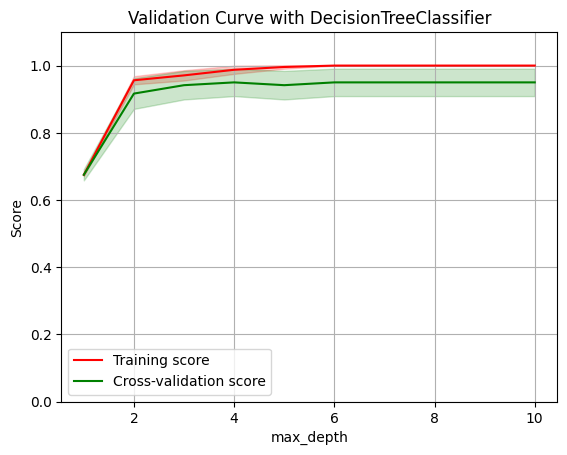

In [80]:
# Plotting model complexity for Decision Tree
param_range = np.arange(1, 11)
plot_model_complexity(DecisionTreeClassifier(criterion='gini', min_samples_split=2, min_samples_leaf=1, random_state=42),
                      "max_depth", param_range, X_train, y_train)


##### k-NN Complexity
We will investigate the impact of the `k` parameter on the k-NN classifier's performance while holding the distance metric constant. Specifically, we will set `metric` to `'euclidean'`. A small value of `k` may lead to overfitting, while a large value of `k` may lead to underfitting [5].


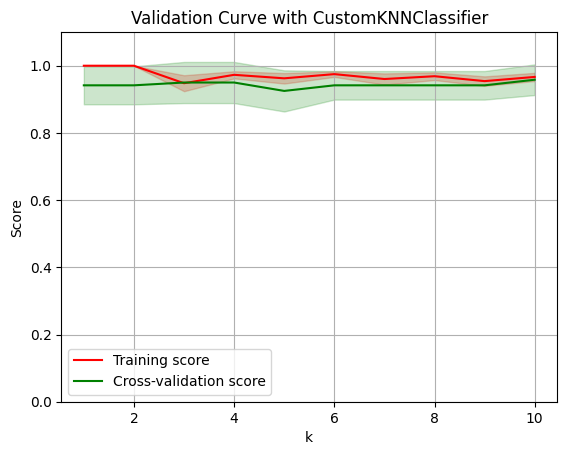

In [81]:
# Plotting model complexity for k-NN
param_range = np.arange(1, 11)
plot_model_complexity(CustomKNNClassifier(metric='euclidean'), "k", param_range, X_train, y_train)


## Results
The results section summarizes the performance of all models, including accuracy, precision, recall, and F1 score. Confusion matrices are also provided for a more comprehensive evaluation.


### Summary of Model Performance

In [82]:
# Train and evaluate the best custom k-NN model on the entire training set
best_knn.fit(X_train, y_train)
y_pred_best_knn = best_knn.predict(X_test)

# Evaluate the best custom k-NN model
accuracy_best_knn = accuracy_score(y_test, y_pred_best_knn)
precision_best_knn = precision_score(y_test, y_pred_best_knn, average='weighted')
recall_best_knn = recall_score(y_test, y_pred_best_knn, average='weighted')
f1_best_knn = f1_score(y_test, y_pred_best_knn, average='weighted')

# Train and evaluate the custom Naive Bayes model on the entire training set
custom_nb.fit(X_train, y_train)
y_pred_custom_nb = custom_nb.predict(X_test)

# Evaluate the custom Naive Bayes model
accuracy_custom_nb = accuracy_score(y_test, y_pred_custom_nb)
precision_custom_nb = precision_score(y_test, y_pred_custom_nb, average='weighted')
recall_custom_nb = recall_score(y_test, y_pred_custom_nb, average='weighted')
f1_custom_nb = f1_score(y_test, y_pred_custom_nb, average='weighted')

# Train the decision tree model on the entire training set
best_tree.fit(X_train, y_train)
y_pred_tree = best_tree.predict(X_test)

# Evaluate the decision tree model
accuracy_tree = accuracy_score(y_test, y_pred_tree)
precision_tree = precision_score(y_test, y_pred_tree, average='weighted')
recall_tree = recall_score(y_test, y_pred_tree, average='weighted')
f1_tree = f1_score(y_test, y_pred_tree, average='weighted')

# Train the best logistic regression model on the entire training set
best_log_reg.fit(X_train, y_train)
y_pred_log_reg = best_log_reg.predict(X_test)

# Evaluate the logistic regression model
accuracy_log_reg = accuracy_score(y_test, y_pred_log_reg)
precision_log_reg = precision_score(y_test, y_pred_log_reg, average='weighted')
recall_log_reg = recall_score(y_test, y_pred_log_reg, average='weighted')
f1_log_reg = f1_score(y_test, y_pred_log_reg, average='weighted')

# Collecting performance metrics
results = {
    'Model': ['k-NN (from scratch)', 'Naive Bayes (from scratch)', 'Decision Tree', 'Logistic Regression'],
    'Optimal Hyperparameter': [
        f"k={best_knn_params['k']}, metric={best_knn_params['metric']}",
        '-',
        f"criterion={best_tree_params['criterion']}, max_depth={best_tree_params['max_depth']}, "
        f"min_samples_split={best_tree_params['min_samples_split']}, min_samples_leaf={best_tree_params['min_samples_leaf']}",
        f"C={best_log_reg_params['C']}, penalty={best_log_reg_params['penalty']}, solver={best_log_reg_params['solver']}"
    ],
    'Accuracy (Validation)': [
        grid_search_knn.best_score_,
        cv_scores_nb.mean(),
        grid_search_tree.best_score_,
        grid_search_log_reg.best_score_
    ],
    'Accuracy (Test)': [accuracy_best_knn, accuracy_custom_nb, accuracy_tree, accuracy_log_reg],
    'Precision (Test)': [precision_best_knn, precision_custom_nb, precision_tree, precision_log_reg],
    'Recall (Test)': [recall_best_knn, recall_custom_nb, recall_tree, recall_log_reg],
    'F1 Score (Test)': [f1_best_knn, f1_custom_nb, f1_tree, f1_log_reg]
}

# Creating the DataFrame
results_df = pd.DataFrame(results)

# Display the summary table
results_df



,Model,Optimal Hyperparameter,Accuracy (Validation),Accuracy (Test),Precision (Test),Recall (Test),F1 Score (Test)
0,k-NN (from scratch),"k=9, metric=manhattan",0.958333,1.0,1.0,1.0,1.0
1,Naive Bayes (from scratch),-,0.941667,1.0,1.0,1.0,1.0
2,Decision Tree,"criterion=entropy, max_depth=None, min_samples...",0.958333,1.0,1.0,1.0,1.0
3,Logistic Regression,"C=1, penalty=l2, solver=lbfgs",0.958333,1.0,1.0,1.0,1.0


#### Custom k-NN Classifier Results
The best custom k-NN classifier was trained and evaluated on the test set. The performance metrics and confusion matrix are displayed below:

Best Custom k-NN Model Performance
Accuracy: 1.00
Precision: 1.00
Recall: 1.00
F1 Score: 1.00

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



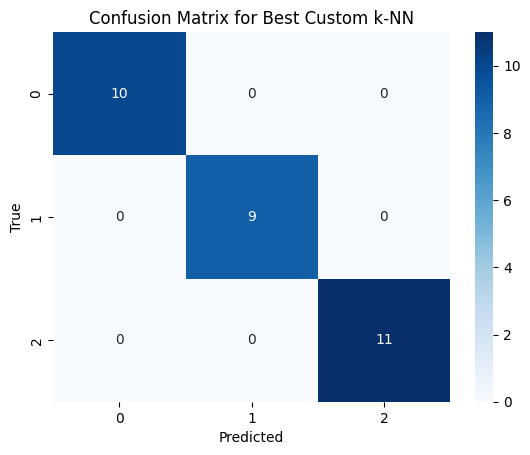

In [83]:
# Custom k-NN Model Performance
print("Best Custom k-NN Model Performance")
print(f"Accuracy: {accuracy_best_knn:.2f}")
print(f"Precision: {precision_best_knn:.2f}")
print(f"Recall: {recall_best_knn:.2f}")
print(f"F1 Score: {f1_best_knn:.2f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred_best_knn))

# Confusion Matrix for best custom k-NN
conf_matrix_best_knn = confusion_matrix(y_test, y_pred_best_knn)
sns.heatmap(conf_matrix_best_knn, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix for Best Custom k-NN')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()


#### Custom k-NN Classifier Results
The best custom k-NN classifier was trained and evaluated on the test set. The performance metrics and confusion matrix are displayed below:


Custom Naive Bayes Model Performance
Accuracy: 1.00
Precision: 1.00
Recall: 1.00
F1 Score: 1.00

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



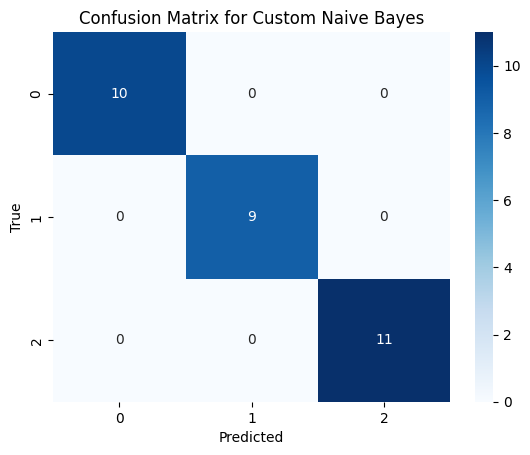

In [84]:
# Custom Naive Bayes Model Performance
print("Custom Naive Bayes Model Performance")
print(f"Accuracy: {accuracy_custom_nb:.2f}")
print(f"Precision: {precision_custom_nb:.2f}")
print(f"Recall: {recall_custom_nb:.2f}")
print(f"F1 Score: {f1_custom_nb:.2f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred_custom_nb))

# Confusion Matrix for custom Naive Bayes
conf_matrix_custom_nb = confusion_matrix(y_test, y_pred_custom_nb)
sns.heatmap(conf_matrix_custom_nb, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix for Custom Naive Bayes')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()


#### Custom Naive Bayes Classifier Results
The custom Naive Bayes classifier was trained and evaluated on the test set. The performance metrics and confusion matrix are displayed below:


Custom Naive Bayes Model Performance
Accuracy: 1.00
Precision: 1.00
Recall: 1.00
F1 Score: 1.00

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



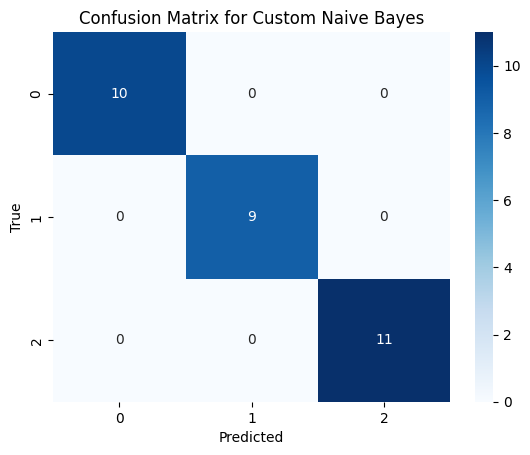

In [85]:
# Custom Naive Bayes Model Performance
print("Custom Naive Bayes Model Performance")
print(f"Accuracy: {accuracy_custom_nb:.2f}")
print(f"Precision: {precision_custom_nb:.2f}")
print(f"Recall: {recall_custom_nb:.2f}")
print(f"F1 Score: {f1_custom_nb:.2f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred_custom_nb))

# Confusion Matrix for custom Naive Bayes
conf_matrix_custom_nb = confusion_matrix(y_test, y_pred_custom_nb)
sns.heatmap(conf_matrix_custom_nb, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix for Custom Naive Bayes')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()


#### Decision Tree Results
The decision tree classifier was trained and evaluated on the test set. The performance metrics and confusion matrix are displayed below:


Decision Tree Model Performance
Accuracy: 1.00
Precision: 1.00
Recall: 1.00
F1 Score: 1.00

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



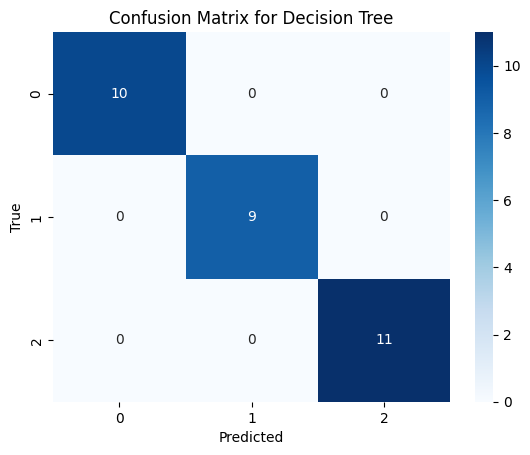

In [86]:
# Decision Tree Model Performance
print("Decision Tree Model Performance")
print(f"Accuracy: {accuracy_tree:.2f}")
print(f"Precision: {precision_tree:.2f}")
print(f"Recall: {recall_tree:.2f}")
print(f"F1 Score: {f1_tree:.2f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred_tree))

# Confusion Matrix for Decision Tree
conf_matrix_tree = confusion_matrix(y_test, y_pred_tree)
sns.heatmap(conf_matrix_tree, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix for Decision Tree')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()


#### Logistic Regression Results
The best logistic regression classifier was trained and evaluated on the test set. The performance metrics and confusion matrix are displayed below:

Logistic Regression Model Performance
Accuracy: 1.00
Precision: 1.00
Recall: 1.00
F1 Score: 1.00

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



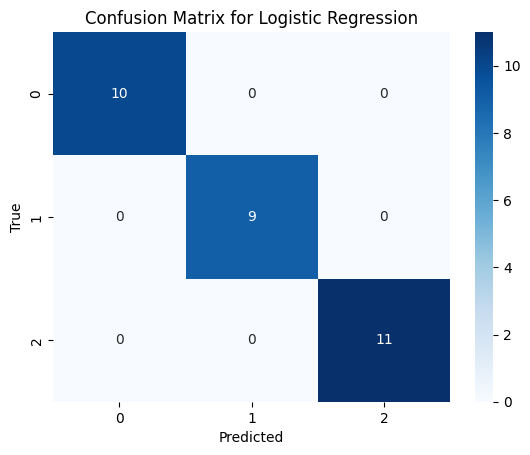

In [87]:
# Logistic Regression Model Performance
print("Logistic Regression Model Performance")
print(f"Accuracy: {accuracy_log_reg:.2f}")
print(f"Precision: {precision_log_reg:.2f}")
print(f"Recall: {recall_log_reg:.2f}")
print(f"F1 Score: {f1_log_reg:.2f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred_log_reg))

# Confusion Matrix for Logistic Regression
conf_matrix_log_reg = confusion_matrix(y_test, y_pred_log_reg)
sns.heatmap(conf_matrix_log_reg, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix for Logistic Regression')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()


## Model Interpretation
Model interpretation is crucial for understanding which features most influence the model's predictions and how the model makes decisions. Decision trees and logistic regression provide feature importance metrics, which we visualize to gain insights into the dataset.

### Feature Importance
Feature importance helps us understand which features contribute the most to the predictions made by the model. For decision trees, feature importance is measured by the decrease in entropy or Gini impurity. For logistic regression, it is measured by the magnitude of the coefficients.

#### Decision Tree Feature Importance
The decision tree model inherently provides feature importance by measuring the decrease in entropy or Gini impurity. Features that lead to significant reductions are considered more important. In our analysis, petal length and petal width were the most important features, which aligns with the high correlations seen in the heatmap.

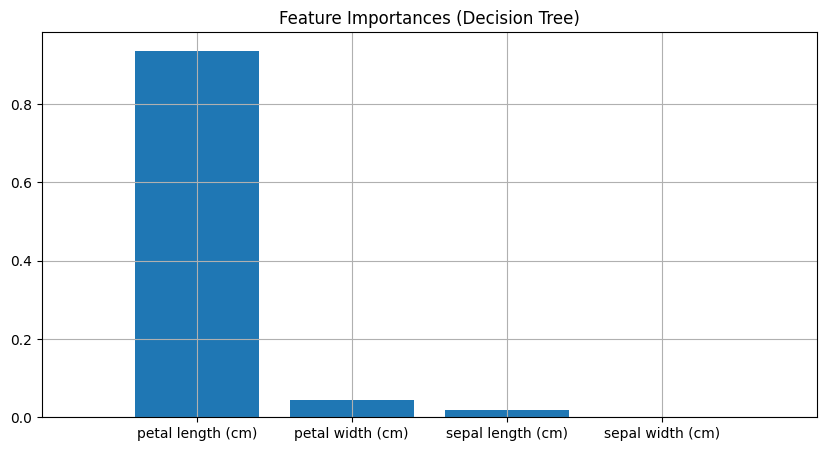

In [88]:
# Feature importance for Decision Tree
importances = best_tree.feature_importances_
feature_names = iris.feature_names
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(10,5))
plt.title("Feature Importances (Decision Tree)")
plt.bar(range(X.shape[1]), importances[indices], align="center")
plt.xticks(range(X.shape[1]), [feature_names[i] for i in indices])
plt.xlim([-1, X.shape[1]])
plt.grid()
plt.show()


#### Logistic Regression Feature Importance
Logistic regression coefficients indicate feature importance, with higher absolute values signifying greater influence on the prediction. The standardized features allowed us to compare the magnitudes of these coefficients directly, revealing that petal width and petal length are the most significant predictors. This supports the separability observed in the t-SNE visualization and the strong correlations in the heatmap.

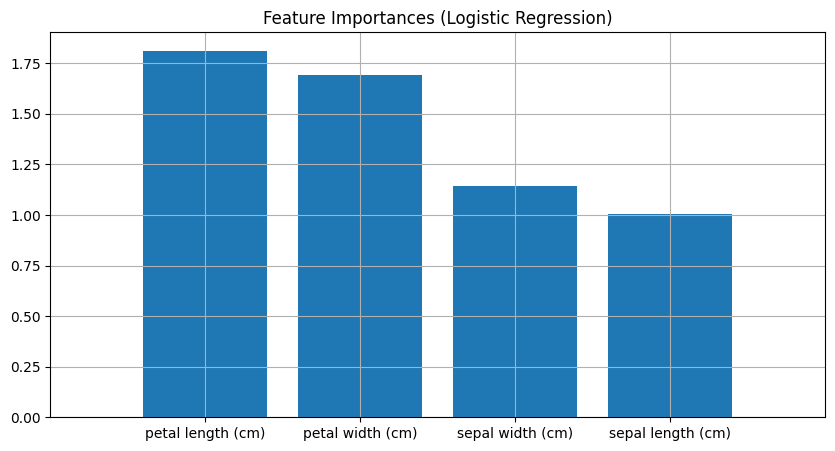

In [89]:
# Feature importance for Logistic Regression
coefficients = np.abs(best_log_reg.coef_[0])
indices = np.argsort(coefficients)[::-1]

plt.figure(figsize=(10, 5))
plt.title("Feature Importances (Logistic Regression)")
plt.bar(range(X.shape[1]), coefficients[indices], align="center")
plt.xticks(range(X.shape[1]), [feature_names[i] for i in indices])
plt.xlim([-1, X.shape[1]])
plt.grid()
plt.show()

### References

1. Breiman, L., Friedman, J., Stone, C. J., & Olshen, R. A. (1984). Classification and Regression Trees. CRC Press.
2. Cover, T., & Hart, P. (1967). Nearest Neighbor Pattern Classification. IEEE Transactions on Information Theory, 13(1), 21-27.
3. Han, J., Kamber, M., & Pei, J. (2011). Data Mining: Concepts and Techniques. Morgan Kaufmann.
4. Hosmer, D. W., Lemeshow, S., & Sturdivant, R. X. (2013). Applied Logistic Regression (Vol. 398). John Wiley & Sons.
5. McCallum, A., & Nigam, K. (1998). A Comparison of Event Models for Naive Bayes Text Classification. In AAAI-98 workshop on learning for text categorization (Vol. 752, No. 1, pp. 41-48).
6. Reimann, C., Filzmoser, P., Garrett, R. G., & Dutter, R. (2008). Statistical Data Analysis Explained: Applied Environmental Statistics with R. John Wiley & Sons.
7. Tukey, J. W. (1977). Exploratory Data Analysis. Addison-Wesley.
8. van der Maaten, L., & Hinton, G. (2008). Visualizing Data using t-SNE. Journal of Machine Learning Research, 9(Nov), 2579-2605.
